In [1]:
# skin_cnn.py
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd



In [2]:
# ---------------------
# Config
# ---------------------
DATA_DIR = "data"            # root folder as described above
TRAIN_DIR = os.path.join(DATA_DIR, "C:/Users/hp/Downloads/kaggle/train")
VAL_DIR   = os.path.join(DATA_DIR, "C:/Users/hp/Downloads/kaggle/val")
TEST_DIR  = os.path.join(DATA_DIR, "C:/Users/hp/Downloads/kaggle/test")

IMG_SIZE = (224, 224)        # standard input size
BATCH_SIZE = 32
EPOCHS = 25
POOLING = "avg"              # for transfer model final pooling
NUM_CLASSES = None           # will be inferred
MODEL_SAVE_PATH = "skin_model.keras"

USE_TRANSFER = True         # set False to run the simple custom CNN



In [3]:
# ---------------------
# Helpers
# ---------------------
def plot_history(history):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title('Accuracy')
    plt.show()

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    plt.figure(figsize=(8,8))
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()



In [4]:
# ---------------------
# Data generators (augmentation)
# ---------------------
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

val_aug = ImageDataGenerator(rescale=1./255)
test_aug = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_aug.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_aug.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 30909 images belonging to 6 classes.
Found 3923 images belonging to 6 classes.
Found 3928 images belonging to 6 classes.


In [5]:
# infer classes / num classes
class_indices = train_gen.class_indices
classes = list(class_indices.keys())
NUM_CLASSES = len(classes)
print("Found classes:", classes)


Found classes: ['1. Enfeksiyonel', '2. Ekzama', '3. Akne', '4. Pigment', '5. Benign', '6. Malign']


In [6]:

# ---------------------
# Build model
# ---------------------
def build_custom_cnn(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out, name='simple_cnn')
    return model

def build_transfer_efficientnet(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        input_shape=input_shape,
        weights='imagenet'
    )
    base_model.trainable = False  # freeze for initial training

    inputs = layers.Input(shape=input_shape)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name='efficientnetb0_transfer')
    return model

if USE_TRANSFER:
    model = build_transfer_efficientnet()
else:
    model = build_custom_cnn()

model.summary()



Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
# ---------------------
# Compile
# ---------------------
initial_lr = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:

# ---------------------
# Callbacks
# ---------------------
cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
cb_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
cb_checkpoint = callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True)

# ---------------------
# (Optional) compute class weights if imbalanced
# ---------------------
# If you want class weights (uncomment to use)
# from sklearn.utils.class_weight import compute_class_weight
# labels = train_gen.classes  # integer labels
# class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
# class_weights_dict = dict(enumerate(class_weights))
# print("Using class weights:", class_weights_dict)
class_weights_dict = None


In [9]:

# ---------------------
# Train
# ---------------------
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=max(1, val_gen.samples // BATCH_SIZE),
    epochs=10,
    callbacks=[cb_early, cb_reduce, cb_checkpoint],
    class_weight=class_weights_dict
)


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1029s 1s/step - accuracy: 0.3347 - loss: 1.6161 - val_accuracy: 0.3486 - val_loss: 1.6026 - learning_rate: 0.0010
Epoch 2/10
  1/965 ━━━━━━━━━━━━━━━━━━━━ 10:35 659ms/step - accuracy: 0.2500 - loss: 1.6935

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


965/965 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2500 - loss: 1.6935 - val_accuracy: 0.0000e+00 - val_loss: 1.5690 - learning_rate: 0.0010
Epoch 3/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 980s 1s/step - accuracy: 0.3520 - loss: 1.5962 - val_accuracy: 0.3486 - val_loss: 1.6023 - learning_rate: 0.0010
Epoch 4/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - accuracy: 0.2812 - loss: 1.7742 - val_accuracy: 0.0000e+00 - val_loss: 1.4407 - learning_rate: 0.0010
Epoch 5/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 922s 956ms/step - accuracy: 0.3505 - loss: 1.5957 - val_accuracy: 0.3486 - val_loss: 1.6074 - learning_rate: 0.0010
Epoch 6/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 433us/step - accuracy: 0.3750 - loss: 1.6459 - val_accuracy: 0.0000e+00 - val_loss: 1.4695 - learning_rate: 0.0010
Epoch 7/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 902s 935ms/step - accuracy: 0.3544 - loss: 1.5868 - val_accuracy: 0.3486 - val_loss: 1.6037 - learning_rate: 0.0010
Epoch 8/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step - accuracy: 0.4688 -

In [10]:

# ---------------------
# (Optional) Fine-tune transfer model
# ---------------------
if USE_TRANSFER:
    # Unfreeze some layers and fine-tune
    base = model.get_layer(index=1)  # EfficientNetB0 base (structure: Input -> lambda preprocess -> base_model ...)
    if hasattr(base, 'trainable'):
        base.trainable = True
        # Freeze first N layers
        fine_tune_at = int(len(base.layers) * 0.7)
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        print("Starting fine-tuning...")
        fine_history = model.fit(
            train_gen,
            steps_per_epoch=train_gen.samples // BATCH_SIZE,
            validation_data=val_gen,
            validation_steps=max(1, val_gen.samples // BATCH_SIZE),
            epochs=10,
            callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
                       callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)]
        )
        # merge history (optional)
        # for k in fine_history.history:
        #     history.history[k] += fine_history.history[k]


Starting fine-tuning...
Epoch 1/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1243s 1s/step - accuracy: 0.2926 - loss: 1.7453 - val_accuracy: 0.3486 - val_loss: 1.5465 - learning_rate: 1.0000e-05
Epoch 2/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 2s 794us/step - accuracy: 0.2812 - loss: 1.6472 - val_accuracy: 0.0000e+00 - val_loss: 1.6062 - learning_rate: 1.0000e-05
Epoch 3/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1150s 1s/step - accuracy: 0.3549 - loss: 1.5537 - val_accuracy: 0.3486 - val_loss: 1.4607 - learning_rate: 1.0000e-05
Epoch 4/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step - accuracy: 0.2500 - loss: 1.5518 - val_accuracy: 0.0000e+00 - val_loss: 1.6063 - learning_rate: 1.0000e-05
Epoch 5/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1090s 1s/step - accuracy: 0.3797 - loss: 1.4868 - val_accuracy: 0.3852 - val_loss: 1.4116 - learning_rate: 1.0000e-05
Epoch 6/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step - accuracy: 0.5312 - loss: 1.4091 - val_accuracy: 0.0000e+00 - val_loss: 1.5748 - learning_rate: 1.0000e-05
Epoch 7/10
965/9

In [11]:

# ---------------------
# Save model (already saved by checkpoint) — but save final anyway
# ---------------------
model.save("final_" + MODEL_SAVE_PATH)

print("Saved model to", "final_" + MODEL_SAVE_PATH)


Saved model to final_skin_model.keras


123/123 ━━━━━━━━━━━━━━━━━━━━ 107s 855ms/step
Classification report:
                 precision    recall  f1-score   support

1. Enfeksiyonel       0.33      0.10      0.15       750
      2. Ekzama       0.35      0.23      0.28       510
        3. Akne       0.00      0.00      0.00       322
     4. Pigment       0.00      0.00      0.00       136
      5. Benign       0.39      0.95      0.55      1361
      6. Malign       0.72      0.02      0.03       849

       accuracy                           0.38      3928
      macro avg       0.30      0.22      0.17      3928
   weighted avg       0.40      0.38      0.26      3928



c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

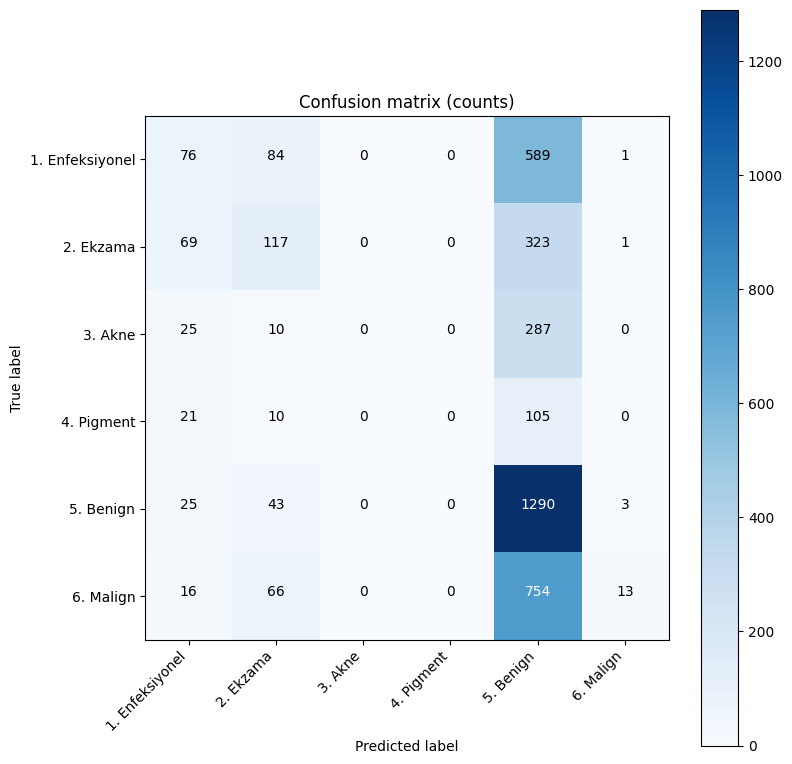

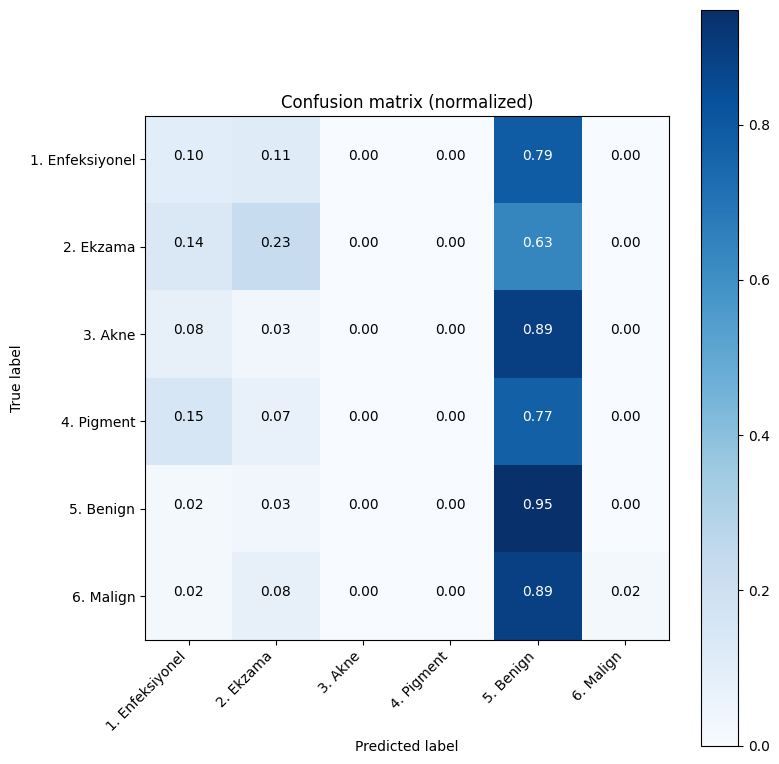

In [12]:

# ---------------------
# Evaluate on test set
# ---------------------
test_steps = int(np.ceil(test_gen.samples / BATCH_SIZE))
preds = model.predict(test_gen, steps=test_steps, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes  # index-aligned

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, classes, normalize=False, title="Confusion matrix (counts)")
plot_confusion_matrix(cm, classes, normalize=True, title="Confusion matrix (normalized)")


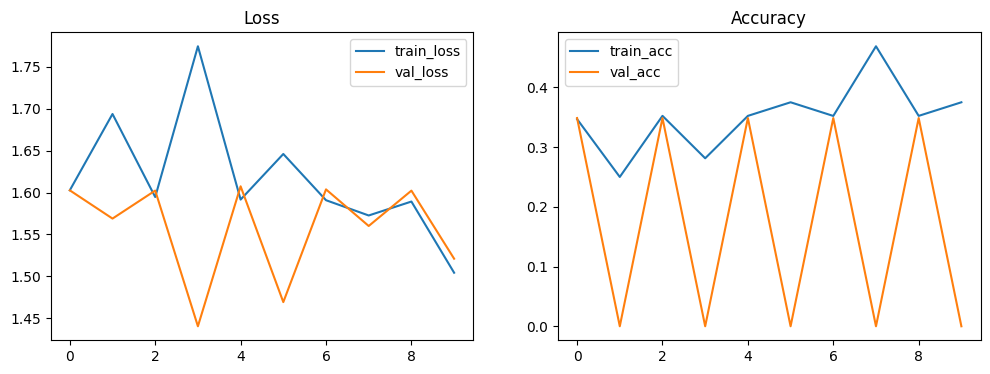

In [13]:

# ---------------------
# Quick inference example
# ---------------------
from tensorflow.keras.preprocessing import image
def predict_image(img_path, model, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    idx = np.argmax(preds[0])
    return classes[idx], preds[0][idx]

# Example (replace with real file)
# sample_path = "data/test/class_0/some_image.jpg"
# pred_class, conf = predict_image(sample_path, model)
# print("Predicted:", pred_class, "confidence:", conf)

# show training curves
plot_history(history)
